In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(suppress=True)

import os
import scanpy as sc
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad('../datasets/Mouse_Hematopoiesis/adata_used.h5ad')
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata.var_names_make_unique()
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata_hsc = adata[adata.obs['label_man'] == 'prog_1', :]
adata_hsc.shape

(1595, 4995)

In [6]:
test = adata_hsc[adata_hsc.obs['meta_clones'].values == str(5), :].copy()
refe = adata_hsc[adata_hsc.obs['meta_clones'].values != str(5), :].copy()

/tmp/ipykernel_2788508/1605401372.py:6: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2788508/1605401372.py:6: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2788508/1605401372.py:7: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


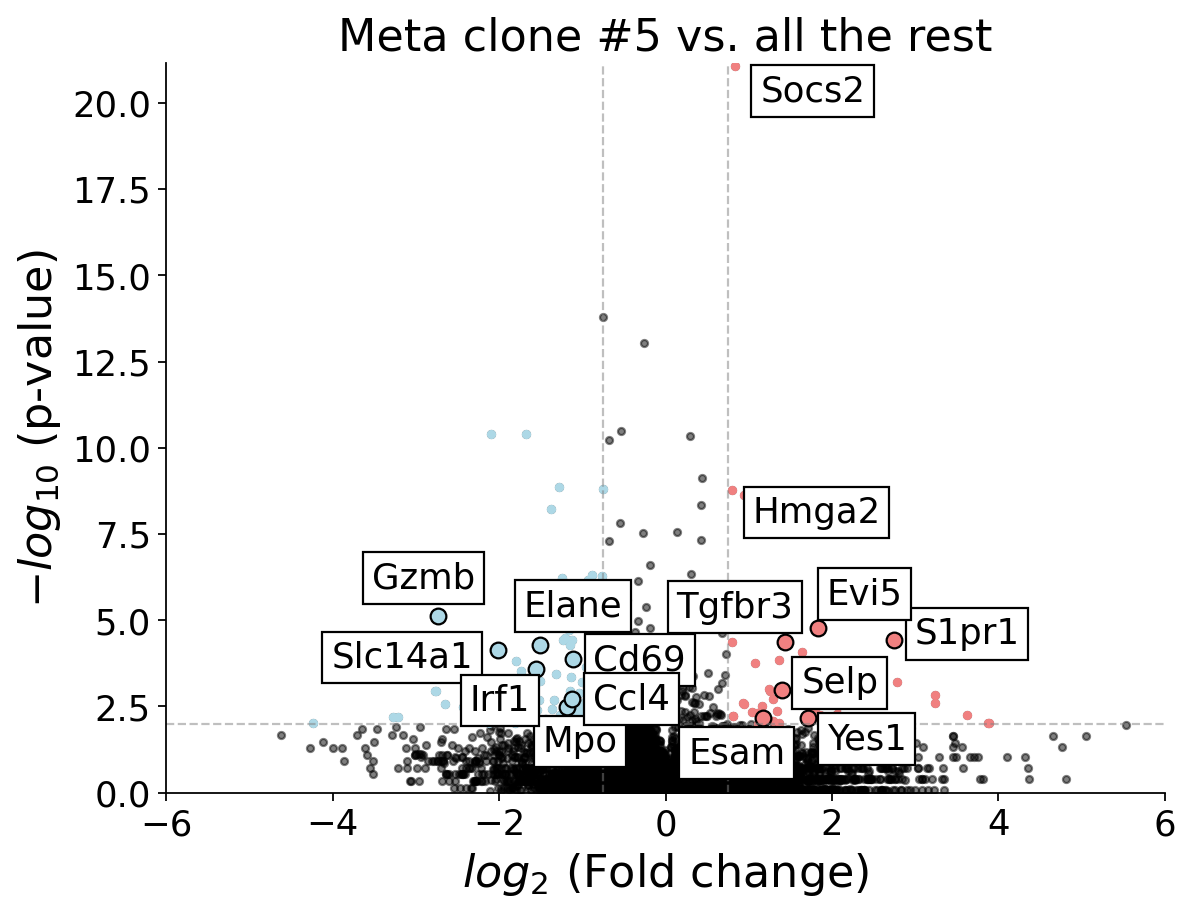

In [16]:
from scipy import stats

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey', alpha=0.5, linewidth=1)
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-0.75, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=1)
plt.vlines(x=0.75, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=1, alpha=0.5)
plt.scatter(lfc[np.bitwise_and(lfc > 0.75, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 0.75, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -0.75, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -0.75, p_values < threshold)], color='lightblue', s=10)


index = [4414, 6728, 15026, 11933, 20726, 13158, 4273]
names = ['Cd69', 'Elane', 'Mpo', 'Gzmb', 'Slc14a1', "Irf1", "Ccl4"]


for i in range(7):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightblue',edgecolors='k', s=50)

t = plt.text(lfc[4414] +0.25, neg_log_10[4414] - 0.3, 'Cd69', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[6728] -0.2, neg_log_10[6728] +0.85 , 'Elane', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[15026] - 0.3, neg_log_10[15026] -1.3 , 'Mpo', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[11933] -0.8, neg_log_10[11933]+0.8 , 'Gzmb', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[20726] -2, neg_log_10[20726]-.5 , 'Slc14a1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[13158] -.8, neg_log_10[13158]-1.2 , 'Irf1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4273] +0.25, neg_log_10[4273] - 0.3, 'Ccl4', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))
###

index = [12363, 20342, 20084, 6947, 7006, 22413, 24638]
names = ["Hoxb7", "Selp" , "S1pr1", "Esam", "Evi5", "Tgfbr3", "Yes1"]

for i in range(7):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightcoral',edgecolors='k', s=50)

t = plt.text(lfc[20342] + 0.23, neg_log_10[20342] - 0.1, 'Selp', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[20084] + 0.25, neg_log_10[20084] -0.1, 'S1pr1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[6947] - 0.9, neg_log_10[6947] - 1.3, 'Esam', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[7006] + 0.1, neg_log_10[7006] + 0.7, 'Evi5', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[22413] -1.3, neg_log_10[22413] + 0.71, 'Tgfbr3', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[24638] + 0.23, neg_log_10[24638] - 0.9, 'Yes1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[21334] + 0.3, neg_log_10[21334] - 1, 'Socs2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[12274] + 0.1, neg_log_10[12274] - 0.8, 'Hmga2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #5 vs. all the rest', fontsize=20)

plt.savefig('de_mouse_mc5_vs_rest.svg', bbox_inches='tight', transparent=True, dpi=300)

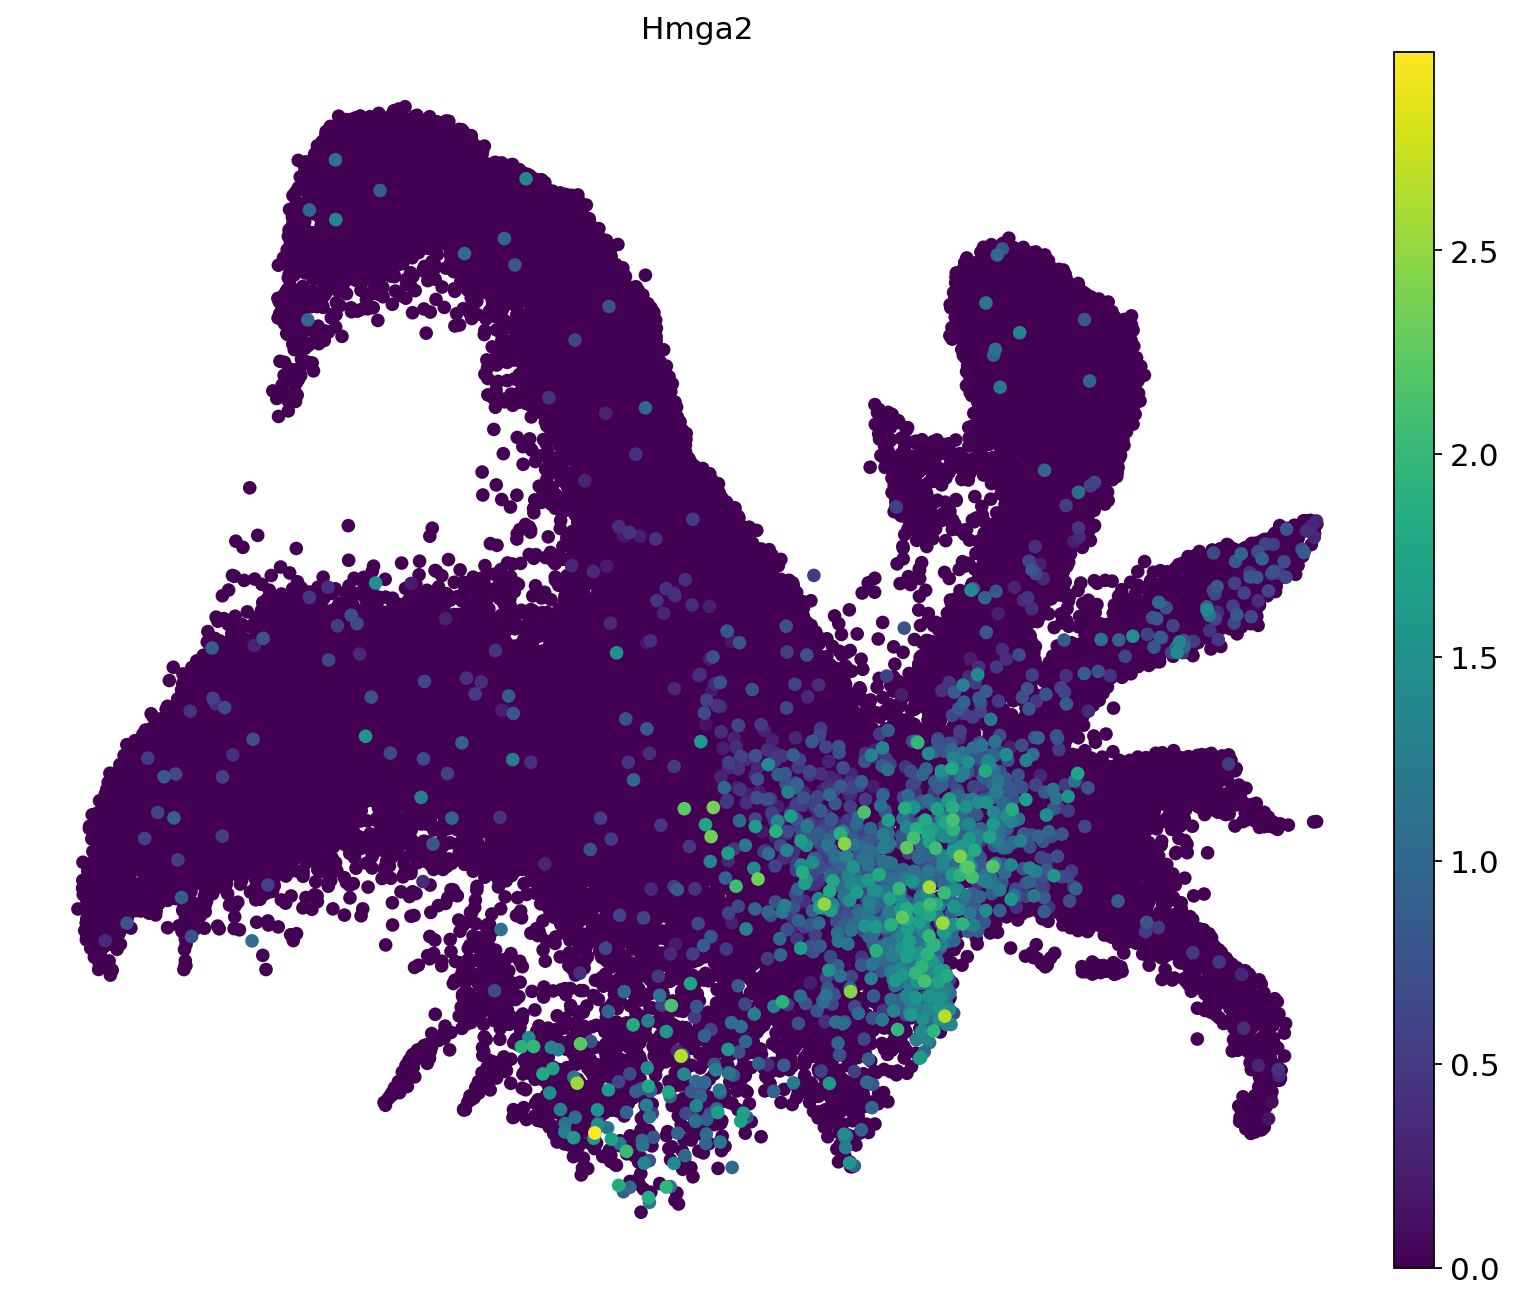

In [19]:
sc.set_figure_params(dpi_save=300, figsize=(12, 10), transparent=True)
sc.pl.umap(adata, color=['Hmga2'], frameon=False, size=150, title='Hmga2', save='_Hmga2.pdf')